# ЛАБОРАТОРНА РОБОТА 7

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from algorithms import differential_evolution, pso

## Функція для завантаження та обробки даних

In [16]:
def load_data(path):
    
    df = pd.read_csv(path)
    
    df = df.map(lambda x: str(x).strip().replace('"', ''))
    df = df.replace(',', '.', regex=True)
    df = df.replace('Е', 'E', regex=True)
    df = df.astype(float)
    
    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values

    return X, y

## Cередньоквадратична помилка
$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} \left( y_i - \mathbf{X}_i \cdot \mathbf{w} \right)^2
$$

In [17]:
def mse_loss(params, X, y):
    return np.mean((y - X @ params) ** 2)

##  L2 регуляризація
$$
L(\mathbf{w}) =
\frac{1}{n} \sum_{i=1}^{n} \left( y_i - \mathbf{X}_i \cdot \mathbf{w} \right)^2
+ \gamma \sum_{j=1}^{m} w_j^2
$$

In [18]:
def ridge_loss(params, X, y, gamma):
    return mse_loss(params, X, y) + gamma * np.sum(params**2)

## L1 регуляризація
$$
L(\mathbf{w}) =
\frac{1}{n} \sum_{i=1}^{n} \left( y_i - \mathbf{X}_i \cdot \mathbf{w} \right)^2
+ \gamma \sum_{j=1}^{m} |w_j|
$$

In [19]:
def lasso_loss(params, X, y, gamma):
    return mse_loss(params, X, y) + gamma * np.sum(np.abs(params))


## Elastic Net 
$$
L(\mathbf{w}) =
\frac{1}{n} \sum_{i=1}^{n} \left( y_i - \mathbf{X}_i \cdot \mathbf{w} \right)^2
+ \gamma_1 \sum_{j=1}^{m} |w_j|
+ \gamma_2 \sum_{j=1}^{m} w_j^2
$$

In [20]:
def elastic_net_loss(params, X, y, g1, g2):
    return (mse_loss(params, X, y) +
            g1 * np.sum(np.abs(params)) +
            g2 * np.sum(params**2))

## Аналітичний розв’язок 
$$
\mathbf{w} =
\left( \mathbf{X}^T \mathbf{X} + \gamma \mathbf{I} \right)^{-1}
\mathbf{X}^T \mathbf{y}
$$

In [21]:
def ridge_analytic(X, y, gamma=0.1):

    n_features = X.shape[1]
    I = np.eye(n_features)
    w = np.linalg.inv(X.T @ X + gamma * I) @ X.T @ y

    return w

## Оцінка моделі

In [22]:
def evaluate(params, X, y):
    y_pred = X @ params
    mse = np.mean((y - y_pred) ** 2)
    return mse

## Функції для побудови графіків

In [23]:
def plot_convergence(loss_de, loss_pso, name):

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(loss_de)
    axes[0].set_title(f"{name} DE ")
    axes[0].set_xlabel("Iteration")
    axes[0].set_ylabel("Loss")
    axes[0].grid()

    axes[1].plot(loss_pso)
    axes[1].set_title(f"{name} PSO")
    axes[1].set_xlabel("Iteration")
    axes[1].set_ylabel("Loss")
    axes[1].grid()
    
    plt.show()

In [24]:
def plot_predictions(X_train, y_train, X_test, y_test, w, title):

    y_train_pred = X_train @ w
    y_test_pred = X_test @ w

    plt.figure(figsize=(8, 8))

    plt.scatter(y_train, y_train_pred, alpha=0.6, label="Train")
    plt.scatter(y_test, y_test_pred, alpha=0.6, label="Test")

    min_val = min(y.min() for y in [y_train, y_test])
    max_val = max(y.max() for y in [y_train, y_test])

    plt.plot(
        [min_val, max_val],
        [min_val, max_val],
        'r--',
        label="Ideal"
    )

    plt.xlabel("True values")
    plt.ylabel("Predicted values")
    plt.title(title)

    plt.legend()
    plt.grid(True)
    plt.show()

## Функція main

In [25]:
# def main(filename):

#     X, y = load_data(filename)

#     X_train, X_test, y_train, y_test = train_test_split(
#         X, y, test_size=0.25, random_state=42, shuffle=True
#     )
    
#     X_train = np.c_[np.ones(len(X_train)), X_train]
#     X_test = np.c_[np.ones(len(X_test)), X_test]

#     n = X_train.shape[1]
#     bounds = [(-10, 10)] * (n)

#     obj = lambda p: mse_loss(p, X_train, y_train)

#     best_de, loss_de = differential_evolution(obj, bounds)
#     best_pso, loss_pso = pso(obj, bounds)

#     ridge_params = ridge_analytic(X_train, y_train, gamma=0.1)

#     obj_ridge = lambda p: ridge_loss(p, X_train, y_train, 0.1)
#     best_de_ridge, loss_de_ridge = differential_evolution(obj_ridge, bounds)
#     best_pso_ridge, loss_pso_ridge = pso(obj_ridge, bounds)

#     obj_lasso = lambda p: lasso_loss(p, X_train, y_train, 0.1)
#     best_de_lasso, loss_de_lasso = differential_evolution(obj_lasso, bounds)
#     best_pso_lasso, loss_pso_lasso = pso(obj_lasso, bounds)


#     obj_elastic = lambda p: elastic_net_loss(p, X_train, y_train, 0.1, 0.1)
#     best_de_elastic, loss_de_elastic = differential_evolution(obj_elastic, bounds)
#     best_pso_elastic, loss_pso_elastic = pso(obj_elastic, bounds)

#     print("\nBASE:", evaluate(best_de, X_test, y_test), evaluate(best_pso, X_test, y_test))

#     print("\nRIDGE:")
#     print("Analytic:", evaluate(ridge_params, X_test, y_test))
#     print("DE:", evaluate(best_de_ridge, X_test, y_test))
#     print("PSO:", evaluate(best_pso_ridge, X_test, y_test))

#     print("\nLASSO:")
#     print("DE:", evaluate(best_de_lasso, X_test, y_test))
#     print("PSO:", evaluate(best_pso_lasso, X_test, y_test))

#     print("\nELASTIC:")
#     print("DE:", evaluate(best_de_elastic, X_test, y_test))
#     print("PSO:", evaluate(best_pso_elastic, X_test, y_test))

#     plot_convergence(loss_de, loss_pso, "BASE")
#     plot_convergence(loss_de_ridge, loss_pso_ridge, "RIDGE")
#     plot_convergence(loss_de_lasso, loss_pso_lasso, "LASSO")
#     plot_convergence(loss_de_elastic, loss_pso_elastic, "ELASTIC")

#     plot_predictions( X_train, y_train, X_test, y_test, best_pso, "PSO Predictions (BASE)")

In [26]:
def main(filename):

    X, y = load_data(filename)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, shuffle=True
    )

    X_train = np.c_[np.ones(len(X_train)), X_train]
    X_test = np.c_[np.ones(len(X_test)), X_test]

    n = X_train.shape[1]
    bounds = [(-10, 10)] * n

    results = []

    obj = lambda p: mse_loss(p, X_train, y_train)

    best_de, loss_de = differential_evolution(obj, bounds)
    best_pso, loss_pso = pso(obj, bounds)

    mse_base_de = evaluate(best_de, X_test, y_test)
    mse_base_pso = evaluate(best_pso, X_test, y_test)

    print("\nBASE:")
    print("DE:", mse_base_de)
    print("PSO:", mse_base_pso)

    results.append({
        "Model": "BASE",
        "Method": "DE",
        "MSE": mse_base_de,
        "Parameters": np.round(best_de, 1).tolist()
    })

    results.append({
        "Model": "BASE",
        "Method": "PSO",
        "MSE": mse_base_pso,
        "Parameters": np.round(best_pso, 1).tolist()
    })


    ridge_params = ridge_analytic(X_train, y_train, gamma=0.1)

    obj_ridge = lambda p: ridge_loss(p, X_train, y_train, 0.1)

    best_de_ridge, loss_de_ridge = differential_evolution(obj_ridge, bounds)
    best_pso_ridge, loss_pso_ridge = pso(obj_ridge, bounds)

    mse_ridge_analytic = evaluate(ridge_params, X_test, y_test)
    mse_ridge_de = evaluate(best_de_ridge, X_test, y_test)
    mse_ridge_pso = evaluate(best_pso_ridge, X_test, y_test)

    print("\nRIDGE:")
    print("Analytic:", mse_ridge_analytic)
    print("DE:", mse_ridge_de)
    print("PSO:", mse_ridge_pso)

    results.append({
        "Model": "RIDGE",
        "Method": "Analytic",
        "MSE": mse_ridge_analytic,
        "Parameters": np.round(ridge_params, 1).tolist()
    })

    results.append({
        "Model": "RIDGE",
        "Method": "DE",
        "MSE": mse_ridge_de,
        "Parameters": np.round(best_de_ridge, 1).tolist()
    })

    results.append({
        "Model": "RIDGE",
        "Method": "PSO",
        "MSE": mse_ridge_pso,
        "Parameters": np.round(best_pso_ridge, 1).tolist()
    })

    obj_lasso = lambda p: lasso_loss(p, X_train, y_train, 0.1)

    best_de_lasso, loss_de_lasso = differential_evolution(obj_lasso, bounds)
    best_pso_lasso, loss_pso_lasso = pso(obj_lasso, bounds)

    mse_lasso_de = evaluate(best_de_lasso, X_test, y_test)
    mse_lasso_pso = evaluate(best_pso_lasso, X_test, y_test)

    print("\nLASSO:")
    print("DE:", mse_lasso_de)
    print("PSO:", mse_lasso_pso)

    results.append({
        "Model": "LASSO",
        "Method": "DE",
        "MSE": mse_lasso_de,
        "Parameters": np.round(best_de_lasso, 1).tolist()
    })

    results.append({
        "Model": "LASSO",
        "Method": "PSO",
        "MSE": mse_lasso_pso,
        "Parameters": np.round(best_pso_lasso, 1).tolist()
    })

    obj_elastic = lambda p: elastic_net_loss(
        p, X_train, y_train, 0.1, 0.1
    )

    best_de_elastic, loss_de_elastic = differential_evolution(
        obj_elastic, bounds
    )

    best_pso_elastic, loss_pso_elastic = pso(
        obj_elastic, bounds
    )

    mse_elastic_de = evaluate(best_de_elastic, X_test, y_test)
    mse_elastic_pso = evaluate(best_pso_elastic, X_test, y_test)

    print("\nELASTIC:")
    print("DE:", mse_elastic_de)
    print("PSO:", mse_elastic_pso)

    results.append({
        "Model": "ELASTIC",
        "Method": "DE",
        "MSE": mse_elastic_de,
        "Parameters": np.round(best_de_elastic, 1).tolist()
    })

    results.append({
        "Model": "ELASTIC",
        "Method": "PSO",
        "MSE": mse_elastic_pso,
        "Parameters": np.round(best_pso_elastic, 1).tolist()
    })

    plot_convergence(loss_de, loss_pso, "BASE")
    plot_convergence(loss_de_ridge, loss_pso_ridge, "RIDGE")
    plot_convergence(loss_de_lasso, loss_pso_lasso, "LASSO")
    plot_convergence(loss_de_elastic, loss_pso_elastic, "ELASTIC")

    plot_predictions( X_train, y_train, X_test, y_test, best_pso, "PSO Predictions (BASE)")

    results_df = pd.DataFrame(results)

    return results_df

## 1. TestRegDataVar9


BASE:
DE: 6.120568716988153
PSO: 10.129684083383292

RIDGE:
Analytic: 0.0009243201420740042
DE: 5.646497210989981
PSO: 7.287203825327465

LASSO:
DE: 6.284891469094012
PSO: 6.379564899560363

ELASTIC:
DE: 7.270882657463986
PSO: 6.558956850119562


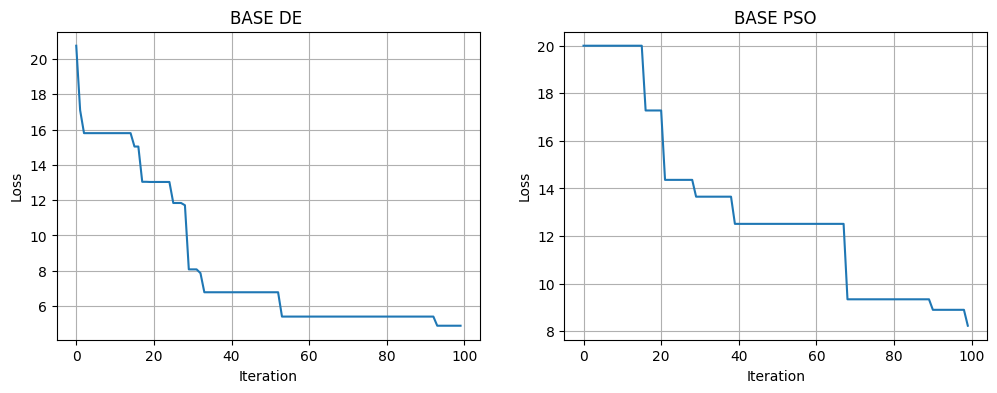

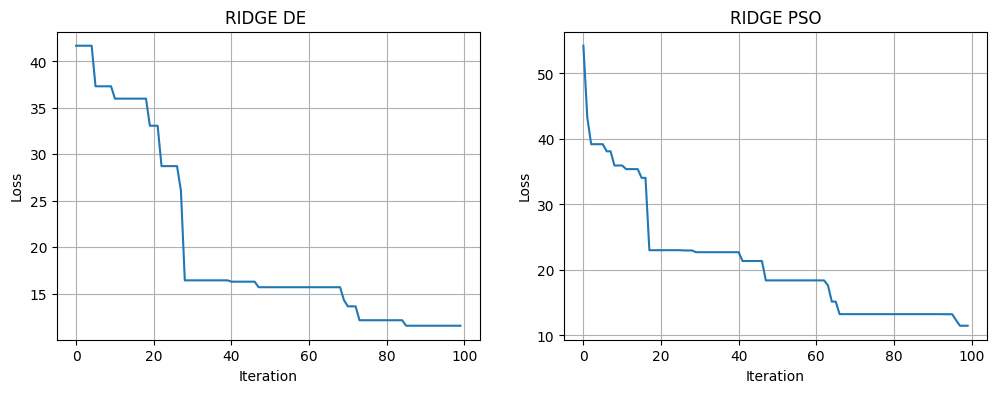

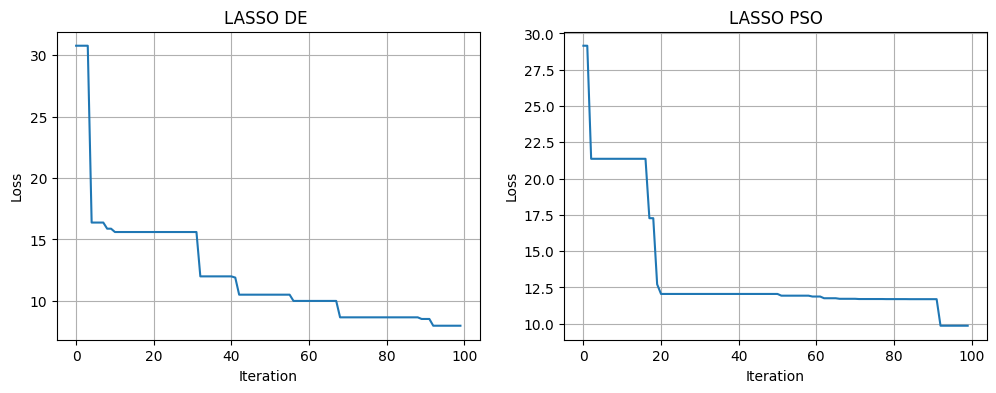

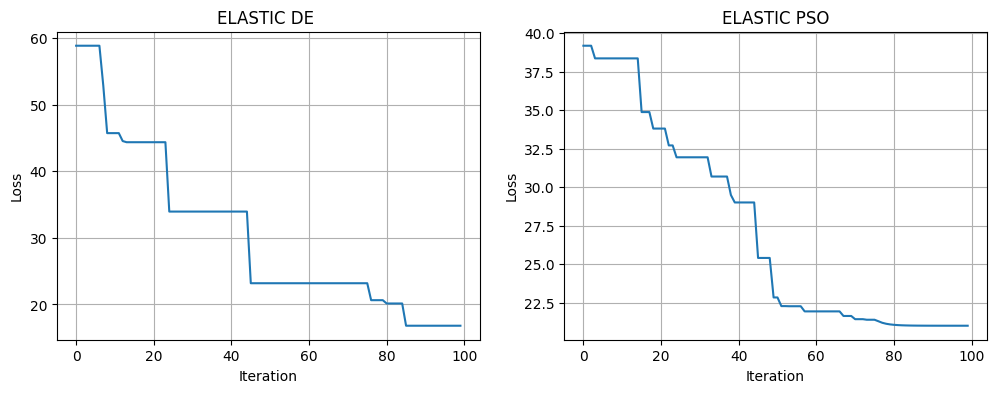

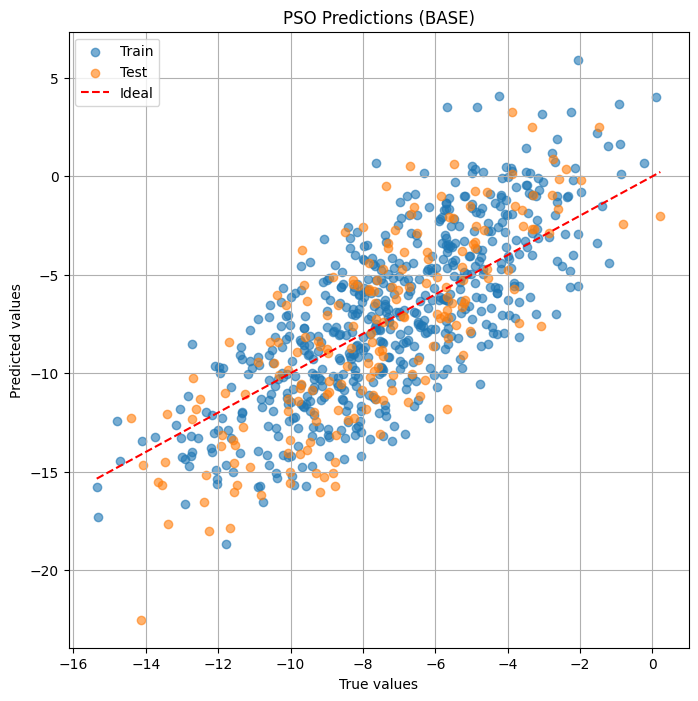

,Model,Method,MSE,Parameters
0,BASE,DE,6.120569,"[-6.1, -4.2, 1.7, -3.3, -7.4, 3.0, 4.4, -1.0, ..."
1,BASE,PSO,10.129684,"[-1.0, -7.1, 4.1, -3.3, -6.8, 9.0, -0.1, -1.3,..."
2,RIDGE,Analytic,0.000924,"[-4.9, -4.0, 1.0, -2.0, -5.0, 5.0, 3.0, -1.0, ..."
3,RIDGE,DE,5.646497,"[-1.9, -2.0, 1.2, -0.4, -1.7, 1.1, 2.3, 0.0, -..."
4,RIDGE,PSO,7.287204,"[-2.5, -2.9, 0.3, -0.2, -4.3, -2.6, -0.3, 0.1,..."
5,LASSO,DE,6.284891,"[-2.8, -4.4, -2.0, 2.9, -1.6, 3.4, 0.5, -3.6, ..."
6,LASSO,PSO,6.379565,"[-8.1, -5.2, -2.0, -1.7, -2.4, 6.2, 2.1, 0.0, ..."
7,ELASTIC,DE,7.270883,"[-0.5, -2.5, -0.3, -2.5, -4.0, -0.3, 2.2, -3.5..."
8,ELASTIC,PSO,6.558957,"[-4.3, -3.7, 0.2, 1.7, -7.1, 1.7, 3.9, -0.8, 0..."


In [30]:
df_results = main("Data/TestRegDataVar9.csv")

df_results

## 2. boston_housing


BASE:
DE: 57.39306853769143
PSO: 49.33103208358322

RIDGE:
Analytic: 12.281507680523102
DE: 112.41793681933493
PSO: 133.0872997588143

LASSO:
DE: 51.67214653697136
PSO: 56.72119678779274

ELASTIC:
DE: 73.8748035663442
PSO: 141.89452267027093


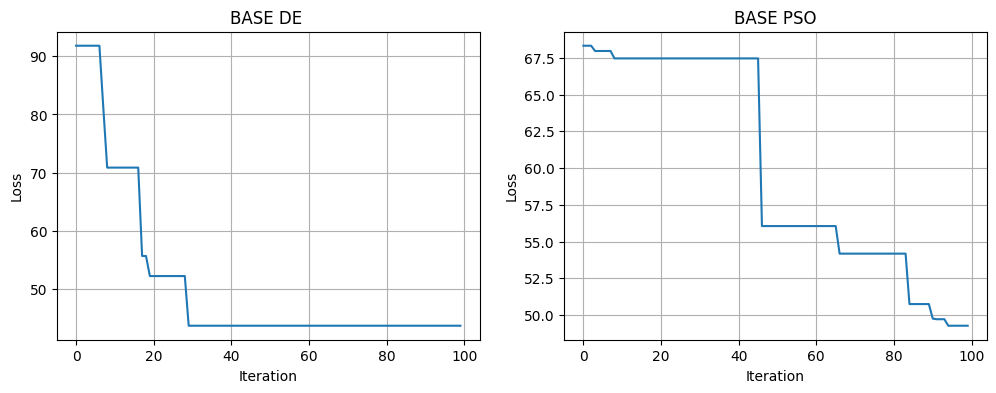

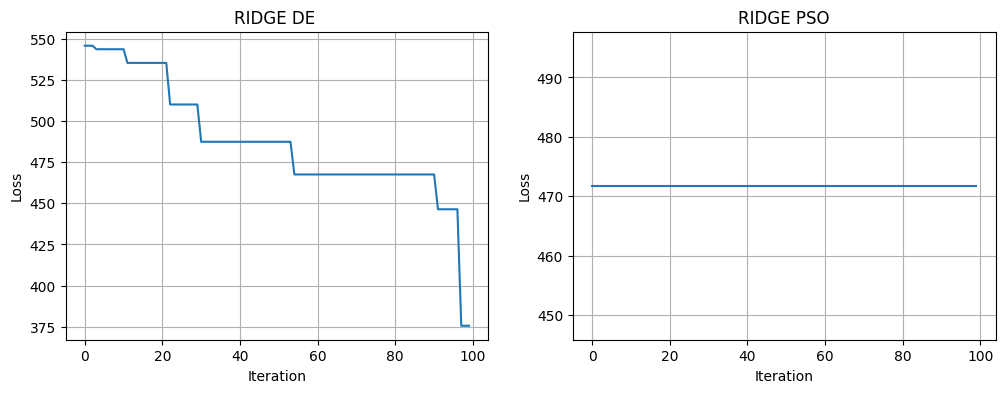

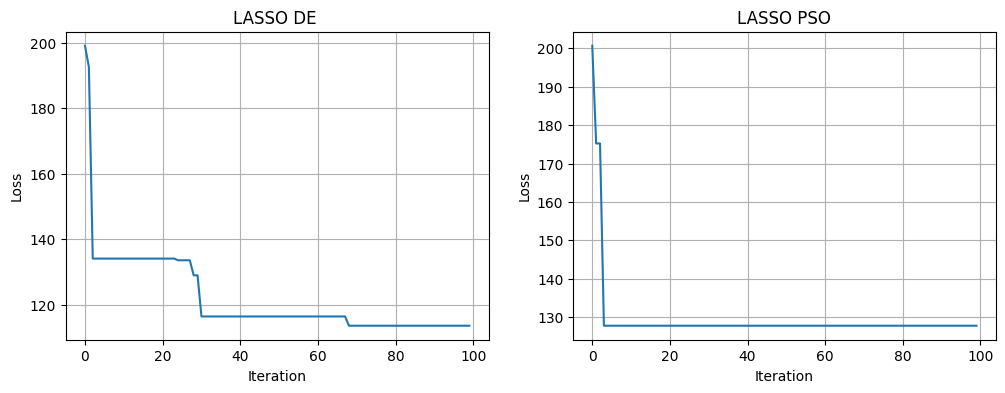

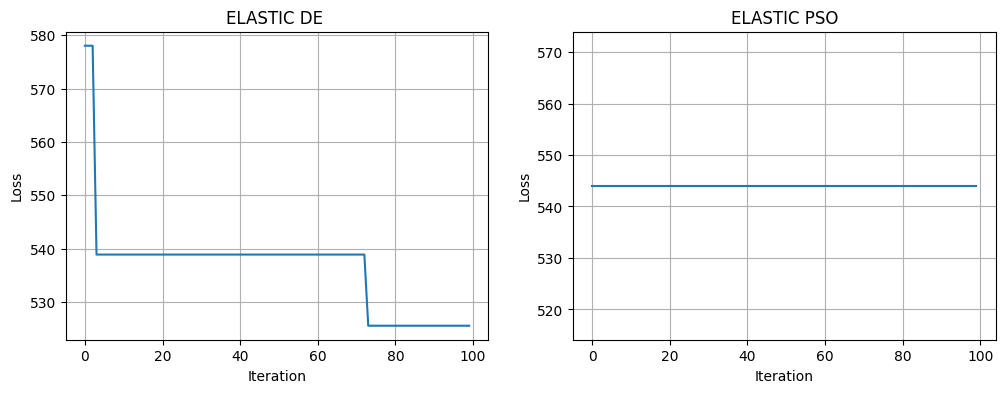

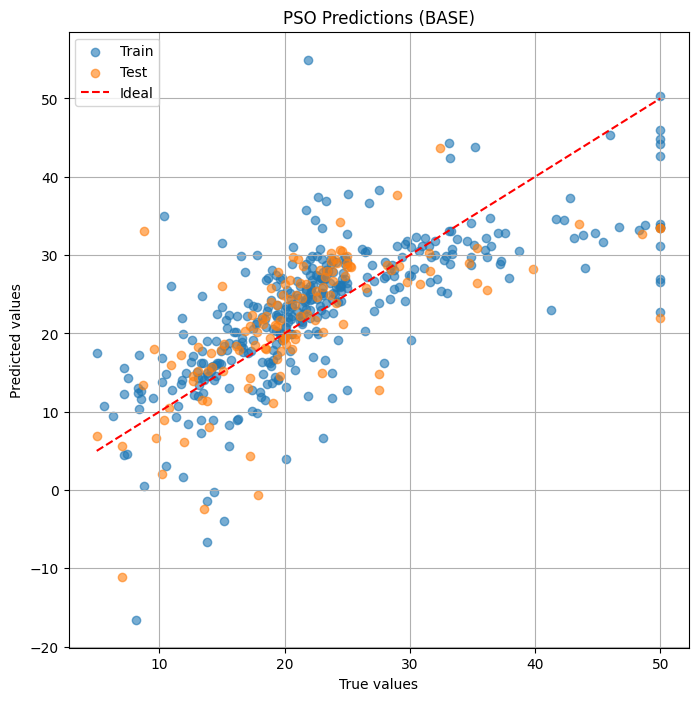

,Model,Method,MSE,Parameters
0,BASE,DE,57.393069,"[9.9, -6.1, 10.0, 10.0, -8.0, -0.5, 10.0, 9.9,..."
1,BASE,PSO,49.331032,"[9.5, 14.9, -3.2, -5.4, -15.7, 0.8, 4.4, -2.8,..."
2,RIDGE,Analytic,12.281508,"[4.3, -3.4, -4.4, -4.1, 6.2, 8.2, 23.1, 4.7, -..."
3,RIDGE,DE,112.417937,"[3.0, -1.2, -1.2, -2.0, -4.6, 0.3, 8.6, 7.5, -..."
4,RIDGE,PSO,133.087300,"[8.2, -1.9, 6.2, 1.5, 3.2, -2.1, -1.3, -3.8, 3..."
5,LASSO,DE,51.672147,"[-2.0, 8.6, 4.9, 5.1, 6.7, 5.6, 9.0, -10.0, 10..."
6,LASSO,PSO,56.721197,"[16.1, 4.8, -11.1, 9.7, 4.5, -7.3, 5.4, 2.7, 7..."
7,ELASTIC,DE,73.874804,"[6.7, 10.0, -9.0, -4.8, 3.1, -8.1, 1.8, 1.4, 5..."
8,ELASTIC,PSO,141.894523,"[1.7, -5.0, 4.4, 4.4, 6.7, -1.9, 9.0, 0.5, 0.1..."


In [35]:
df_results = main("Data/boston_housing.csv")

df_results